<a href="https://colab.research.google.com/github/bala-baskar/aiml_tech_courses/blob/main/pytorch_ultimate/mastering_pytorch_nb1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [44]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import kagglehub

In [46]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("imnikhilanand/heart-attack-prediction")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/heart-attack-prediction


In [47]:
df = pd.read_csv(os.path.join(path,'data.csv'))
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,28,1,2,130,132,0,2,185,0,0.0,?,?,?,0
1,29,1,2,120,243,0,0,160,0,0.0,?,?,?,0
2,29,1,2,140,?,0,0,170,0,0.0,?,?,?,0
3,30,0,1,170,237,0,1,170,0,0.0,?,?,6,0
4,31,0,2,100,219,0,1,150,0,0.0,?,?,?,0


In [48]:
df = df.replace("?",np.nan)
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,1
chol,23
fbs,8
restecg,1
thalach,1
exang,1
oldpeak,0


In [49]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer()
df = pd.DataFrame(imputer.fit_transform(df),columns=df.columns)

In [50]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,28.0,1.0,2.0,130.0,132.000000,0.0,2.0,185.0,0.0,0.0,1.894231,0.0,5.642857,0.0
1,29.0,1.0,2.0,120.0,243.000000,0.0,0.0,160.0,0.0,0.0,1.894231,0.0,5.642857,0.0
2,29.0,1.0,2.0,140.0,250.848708,0.0,0.0,170.0,0.0,0.0,1.894231,0.0,5.642857,0.0
3,30.0,0.0,1.0,170.0,237.000000,0.0,1.0,170.0,0.0,0.0,1.894231,0.0,6.000000,0.0
4,31.0,0.0,2.0,100.0,219.000000,0.0,1.0,150.0,0.0,0.0,1.894231,0.0,5.642857,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
289,52.0,1.0,4.0,160.0,331.000000,0.0,0.0,94.0,1.0,2.5,1.894231,0.0,5.642857,1.0
290,54.0,0.0,3.0,130.0,294.000000,0.0,1.0,100.0,1.0,0.0,2.000000,0.0,5.642857,1.0
291,56.0,1.0,4.0,155.0,342.000000,1.0,0.0,150.0,1.0,3.0,2.000000,0.0,5.642857,1.0
292,58.0,0.0,2.0,180.0,393.000000,0.0,0.0,110.0,1.0,1.0,2.000000,0.0,7.000000,1.0


In [51]:
df.rename(columns={'num       ':'target'},inplace=True)

In [52]:
X = np.array(df.drop(['target'],axis=1))
y = np.array(df['target'])
print(X.shape, y.shape)

(294, 13) (294,)


In [53]:
X_train,X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=123)
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(205, 13) (89, 13) (205,) (89,)


In [54]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [78]:
class SinglePerceptron:
  def __init__(self,alpha,X_train,y_train,X_test,y_test):
    self.w = np.random.randn(X_train.shape[1])
    self.b = np.random.randn()
    self.alpha = alpha
    self.X_train = X_train
    self.y_train = y_train
    self.X_test = X_test
    self.y_test = y_test
    self.train_loss = []
    self.test_loss = []

  def activation(self,x):
    return 1 / (1 + np.exp(-x)) # sigmoid function

  def derivative(self,x):
    return self.activation(x) * (1 - self.activation(x))

  def forward(self,X):
    a = np.dot(X,self.w) + self.b
    z = self.activation(a)
    return z

  def backward(self,X,y_true):
    y_pred = self.forward(X)
    dL_dpred = 2 * (y_pred - y_true)
    a = np.dot(X,self.w) + self.b
    dpred_da = self.derivative(a)
    da_db = 1
    da_dw = X

    dL_db = dL_dpred * dpred_da * da_db
    dL_dw = dL_dpred * dpred_da * da_dw

    return dL_dw, dL_db

  def optimizer(self,dL_dw, dL_db):

    #update weights
    self.b = self.b - self.alpha*dL_db
    self.w = self.w - self.alpha*dL_dw

  def train(self,iterations=10):

    for i in range(iterations):
      #random position of parameters
      random_pos = np.random.randint(len(self.X_train))
      #forward pass
      y_train_true = self.y_train[random_pos]
      y_train_pred = self.forward(self.X_train[random_pos])

      #calculate training loss
      loss = np.sum(np.square(y_train_true - y_train_pred))
      # self.train_loss.append(loss)

      #calculate gradients
      dL_dw, dL_db = self.backward(self.X_train[random_pos],self.y_train[random_pos])

      #update weights
      self.optimizer(dL_dw, dL_db)
      loss_sum = 0
      #calc error for test data
      for j in range(len(self.X_test)):
        y_true = self.y_test[j]
        y_pred = self.forward(self.X_test[j])
        # print(y_true,y_pred)
        loss_sum += np.square(y_pred - y_true)
      self.test_loss.append(loss_sum)

      #calc error for train data
      tr_loss_sum = 0
      for t in range(len(self.X_train)):
        y_true = self.y_train[t]
        y_pred = self.forward(self.X_train[t])
        # print(y_true,y_pred)
        tr_loss_sum += np.square(y_pred - y_true)
      self.train_loss.append(tr_loss_sum)

    return "training successful"

In [82]:
alpha = 0.1
iterations = 2000

nn = SinglePerceptron(alpha=alpha,X_train=X_train,y_train=y_train,X_test=X_test,y_test=y_test)
nn.train(iterations=iterations)

'training successful'

<Axes: >

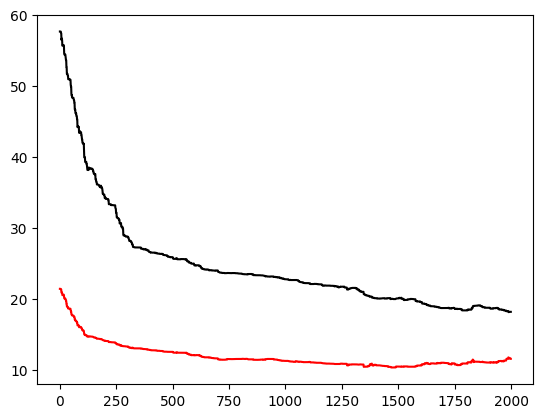

In [83]:
sns.lineplot(x=list(range(len(nn.test_loss))),y=nn.test_loss,color='red')
sns.lineplot(x=list(range(len(nn.train_loss))),y=nn.train_loss,color='black')

In [84]:
nn.w, nn.b

(array([-0.01250971,  1.18085443,  1.09098804, -0.77966689,  0.89741429,
         0.65519243,  0.12785885, -0.05714756,  0.79590911,  1.3572496 ,
         1.26054182,  0.75526243,  0.68459351]),
 np.float64(-1.4919367213216403))

In [86]:
pd.DataFrame({'features':df.drop(['target'],axis=1).columns,'weights':nn.w})

,features,weights
0,age,-0.012510
1,sex,1.180854
2,cp,1.090988
3,trestbps,-0.779667
4,chol,0.897414
5,fbs,0.655192
6,restecg,0.127859
7,thalach,-0.057148
8,exang,0.795909
9,oldpeak,1.357250


In [89]:
final_pred = np.where(nn.activation(np.dot(X_test,nn.w) + nn.b) > 0.5,1,0)
final_pred

array([1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0,
       1])

In [90]:
pd.crosstab(y_test,final_pred)

col_0,0,1
row_0,,
0.0,51,4
1.0,9,25


In [91]:
accuracy = (51 + 25) / (51+25+4+9)
accuracy

0.8539325842696629

### Tensor basics with Pytorch

In [92]:
# Gradients are calculated automatically
import torch

x = torch.tensor(1.0, requires_grad=True)

y = (x - 3) * (x - 6) * (x - 4)

#calculate gradients
y.backward()

print(x.grad)

tensor(31.)


<Axes: >

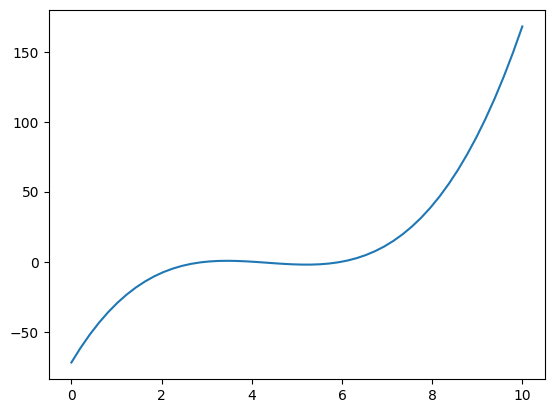

In [93]:
y = lambda x: (x-3) * (x-6) * (x-4)
sns.lineplot(x=np.linspace(0,10),y= y(np.linspace(0,10)))

In [95]:
x = torch.tensor(1.0, requires_grad=True)
y = 3*(x**3)
z = 5*y - 4
z.backward()
print(x.grad)

tensor(45.)
